# Heart Disease EDA

### Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Insert heart dataset

In [3]:
heart_data = pd.read_csv("heart.csv")
df = pd.DataFrame(heart_data)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Fundamental insights of the heart dataset

In [4]:
rows, columns = heart_data.shape
print(f"The heart dataset consists of {rows} rows and {columns} columns")

The heart dataset consists of 303 rows and 14 columns


In [5]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


As the above chart shows:

1. This is a Complete numerical Dataset

2. There is no missing values in any column



### Check for no missing values: 

In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### A histogram of the all features

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>, <Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

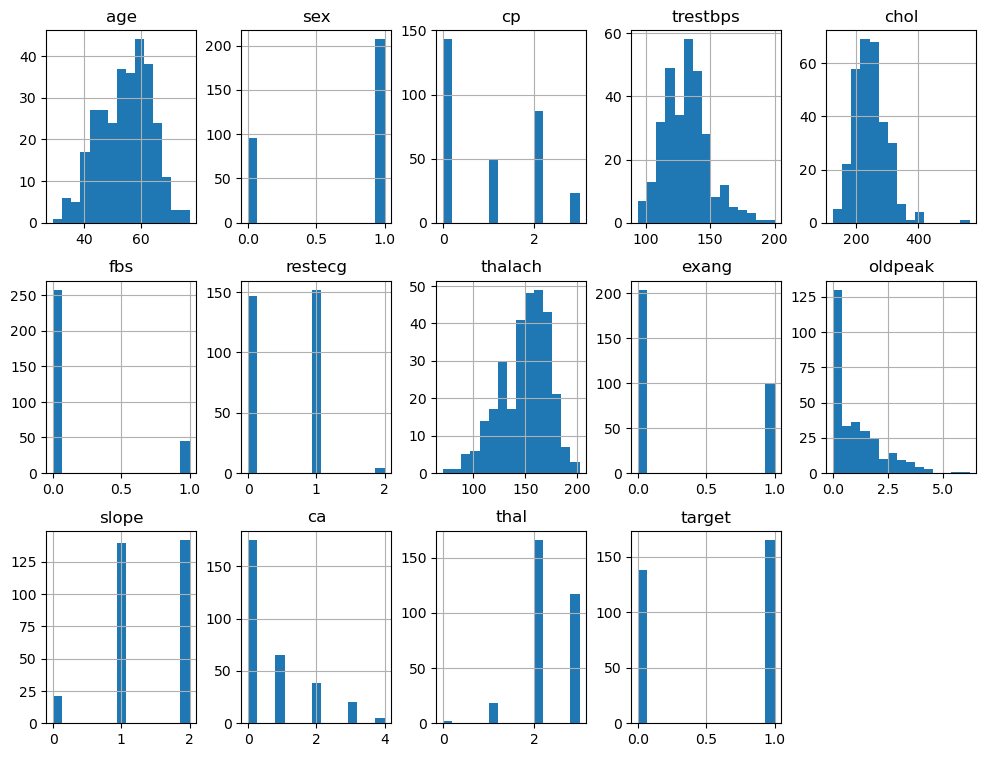

In [7]:
df.hist(figsize=(12,9), bins=15, layout=(3,5))

### Data Type of Features:

**Discrete Features:** 

*Binary:* sex, fbs, Restecg, exang, target

*Non Binary*:  Cp,  slope, ca, thal,

**Continuous Features:** age, trestbps, oldpeak, chol, thalach

In [8]:
font_title = {'family':'Times New Roman', 'color':'blue', 'fontsize':15}
font1 = {'family':'Times New Roman', 'color':'black', 'fontsize':14}
font2 = {'family':'Times New Roman', 'color':'black', 'fontsize':13}

### Unbalanced Dataset in *Sex* feature

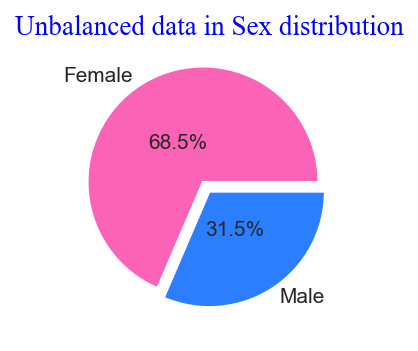

In [117]:
frames = df['sex'].value_counts()
fig, ax = plt.subplots(figsize=(5,2.5),dpi=150)
ax.pie(frames.values, labels=['Female', 'Male'], autopct="%1.1f%%", pctdistance=0.4, explode=(0.1,0), colors=['#FB64B6',"#2B7FFF"])
ax.set_title('Unbalanced data in Sex distribution', fontdict=font_title, fontsize=13)
plt.show()

### Outliers and Noise Removal

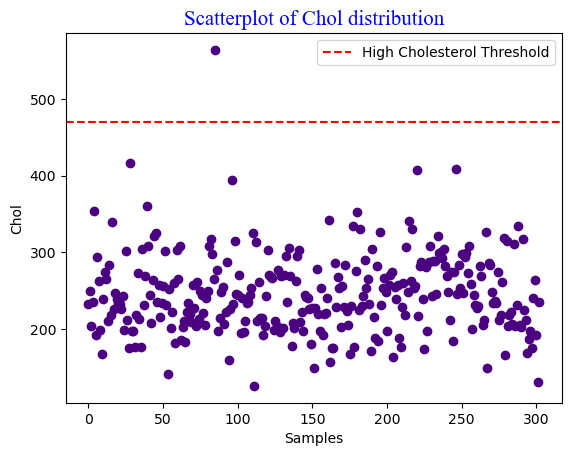

In [10]:
plt.scatter(df.index,  df['chol'], color='indigo', marker='o')
plt.xlabel('Samples')
plt.ylabel('Chol')
plt.title('Scatterplot of Chol distribution', fontdict=font_title)
plt.axhline(y=470, color='r', linestyle='--', label='High Cholesterol Threshold')
plt.legend()
plt.show()

There is an outlier in Cholestrol! 

In [11]:
# Delete the detected outlier
df = df[df['chol'] < 500]

C:\Users\hanaa\AppData\Local\Temp\ipykernel_5828\1249455716.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


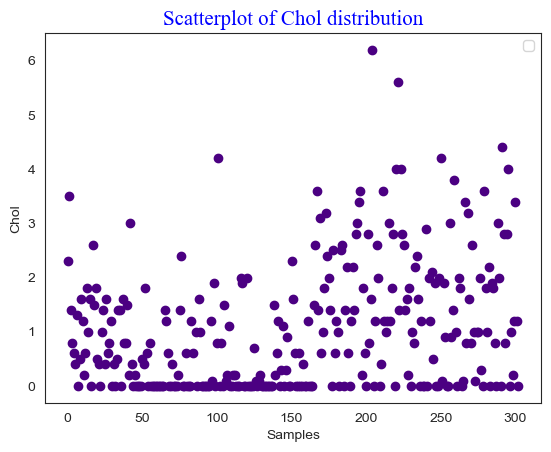

In [20]:
plt.scatter(df.index,  df['oldpeak'], color='indigo', marker='o')
plt.xlabel('Samples')
plt.ylabel('Chol')
plt.title('Scatterplot of Chol distribution', fontdict=font_title)
# plt.axhline(y=470, color='r', linestyle='--', label='High Cholesterol Threshold')
plt.legend()
plt.show()

### Age Distribution

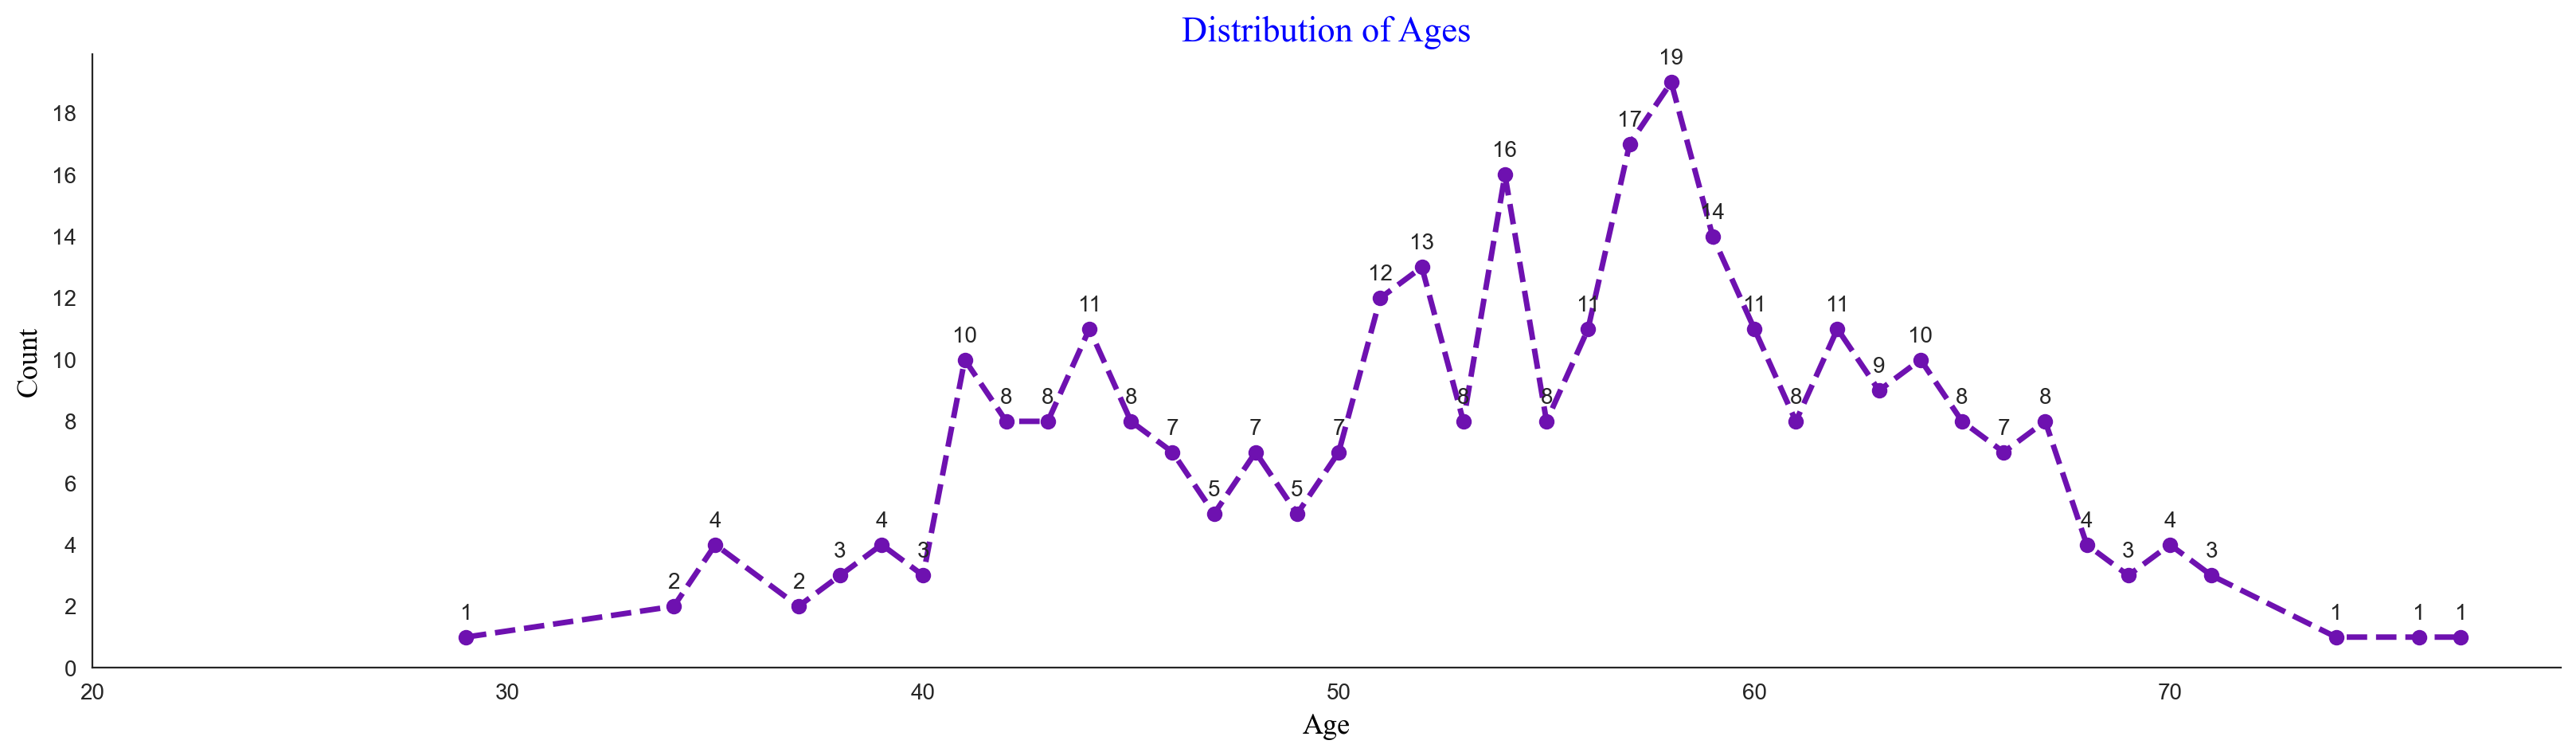

In [89]:
age_counts = df['age'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(20,5), dpi=200)

ax.plot(age_counts.index,
         age_counts.values,
         '--o',
         color='#6E11B0',
         linewidth=2.5)

ax.set_xlabel("Age", fontsize=13,  fontdict=font1)
ax.set_ylabel("Count", fontsize=13, fontdict=font1)
ax.set_yticks(range(0,20,2))
ax.set_xticks(range(20,80,10))
ax.set_title("Distribution of Ages", fontsize=16, fontdict=font_title)

for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

for x, y in zip(age_counts.index, age_counts.values):
    ax.annotate(str(y),
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha='center',
                 fontsize=10)

plt.show()


### Relations of features with target value
Q1: Which type of *chest pain* is most strongly associated with a positive Heart Disease?

Text(0.5, 1.0, 'Chest Pain Type vs Heart Disease Target')

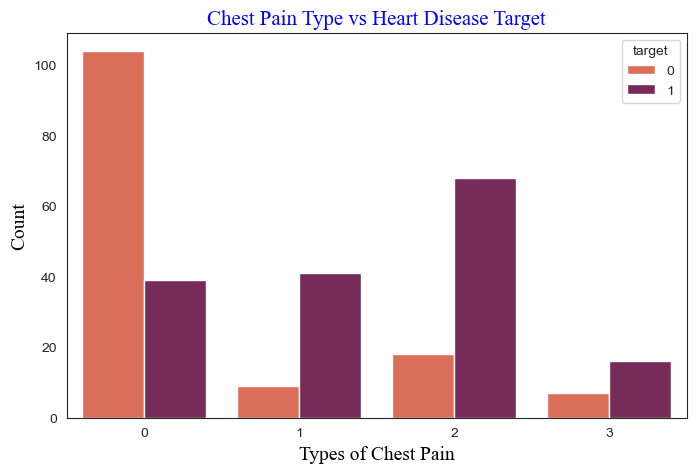

In [103]:
# Count occurrences of each cp type for each target value
cp_target_counts = df.groupby(['cp', 'target']).size().reset_index(name='count')
plt.figure(figsize=(8, 5))  
# grouped bar chart
ax = sns.barplot(x='cp', y='count', hue='target', palette='rocket_r', data=cp_target_counts)
plt.xlabel('Types of Chest Pain', fontdict=font1)
plt.ylabel('Count', fontdict=font1)
plt.title('Chest Pain Type vs Heart Disease Target', fontdict=font_title)


**Note:**

 A significant number of healthy patients do not have chest pain. 

People with Chest Pain type 2 are more likely to have Heart disease.

Q2: Does *Exercise induced angina* decrease the likelihood of the positive Heart Disease?

Text(0.5, 1.0, 'Exercise-induced anigna vs Heart Disease Target')

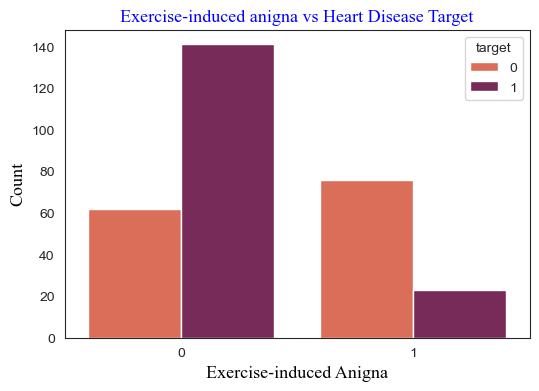

In [104]:
# Count occurrences of each cp type for each target value
ex_target_counts = df.groupby(['exang', 'target']).size().reset_index(name='count')
plt.figure(figsize=(6, 4))  
# grouped bar chart
ax = sns.barplot(x='exang', y='count', hue='target', palette='rocket_r', data=ex_target_counts)
plt.xlabel('Exercise-induced Anigna', fontdict=font2)
plt.ylabel('Count', fontdict=font2)
plt.title('Exercise-induced anigna vs Heart Disease Target', fontdict=font_title, fontsize=13)


**Note:** A significantly higher number of these patients have heart disease compared to those who do not. (Strange Data!)

Q3:  Is *fasting blood sugar* a good indicator of Heart Disease?

Text(0.5, 1.0, 'Fasting blood sugar vs Heart Disease Target')

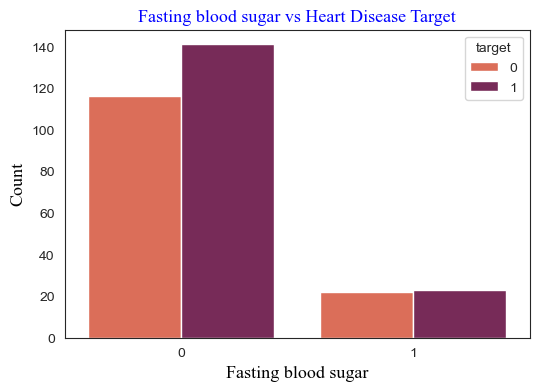

In [105]:
# Count occurrences of each cp type for each target value
fbs_target_counts = df.groupby(['fbs', 'target']).size().reset_index(name='count')
plt.figure(figsize=(6, 4))  
# grouped bar chart
ax = sns.barplot(x='fbs', y='count', hue='target', palette='rocket_r', data=fbs_target_counts)
plt.xlabel('Fasting blood sugar', fontdict=font2)
plt.ylabel('Count', fontdict=font2)
plt.title('Fasting blood sugar vs Heart Disease Target', fontdict=font_title, fontsize=13)


**Note:** The proportion of people with heart disease is almost the same whether their fasting blood sugar is normal Since knowing the fbs value doesn’t really help you distinguish between patients with and without heart disease, it’s considered a poor predictive feature.

Q4:   Is there a significant difference in cholesterol levels between the Healthy and Heart Diseased groups?

Q5:  Do patients with heart disease reach higher or lower maximum heart rates?

Q6:   Is there a significant difference in ST Depresson levels between the Healthy and Heart Diseased groups?

C:\Users\hanaa\AppData\Local\Temp\ipykernel_5828\138897953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='chol', palette='rocket_r', data=df, ax=ax1)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_5828\138897953.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='thalach', palette='rocket_r', data=df, ax=ax2)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_5828\138897953.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='oldpeak', palette='rocket_r', data=df, ax=ax3)


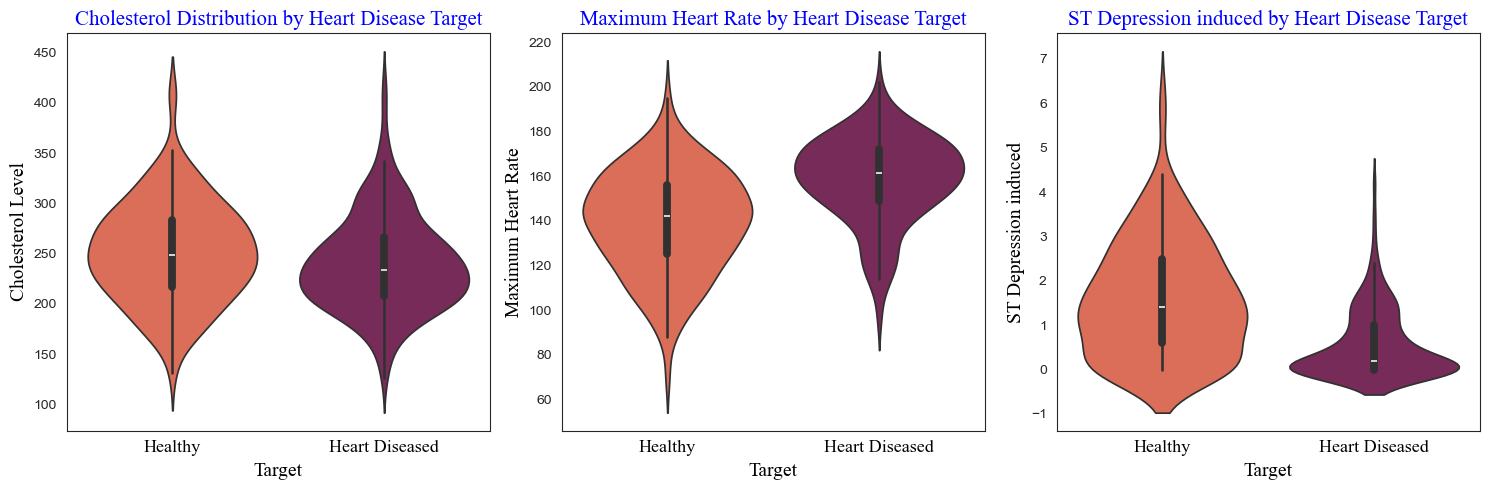

In [99]:
fig, (ax1, ax2, ax3)  = plt.subplots(1,3,figsize=(15,5))

sns.violinplot(x='target', y='chol', palette='rocket_r', data=df, ax=ax1)
ax1.set_xlabel('Target', fontdict=font1)
ax1.set_ylabel('Cholesterol Level', fontdict=font1)
ax1.set_title('Cholesterol Distribution by Heart Disease Target', fontdict=font_title)
ax1.set_xticks([0, 1], ['Healthy', 'Heart Diseased'], fontdict=font2)

sns.violinplot(x='target', y='thalach', palette='rocket_r', data=df, ax=ax2)
ax2.set_xlabel('Target', fontdict=font1)
ax2.set_ylabel('Maximum Heart Rate', fontdict=font1)
ax2.set_title('Maximum Heart Rate by Heart Disease Target', fontdict=font_title)
ax2.set_xticks([0, 1], ['Healthy', 'Heart Diseased'], fontdict=font2)

sns.violinplot(x='target', y='oldpeak', palette='rocket_r', data=df, ax=ax3)
ax3.set_xlabel('Target', fontdict=font1)
ax3.set_ylabel('ST Depression induced', fontdict=font1)
ax3.set_title('ST Depression induced by Heart Disease Target', fontdict=font_title)
ax3.set_xticks([0, 1], ['Healthy', 'Heart Diseased'], fontdict=font2)

plt.tight_layout()

### Correlation in Continues Features

<Axes: title={'center': 'Correlation of features'}>

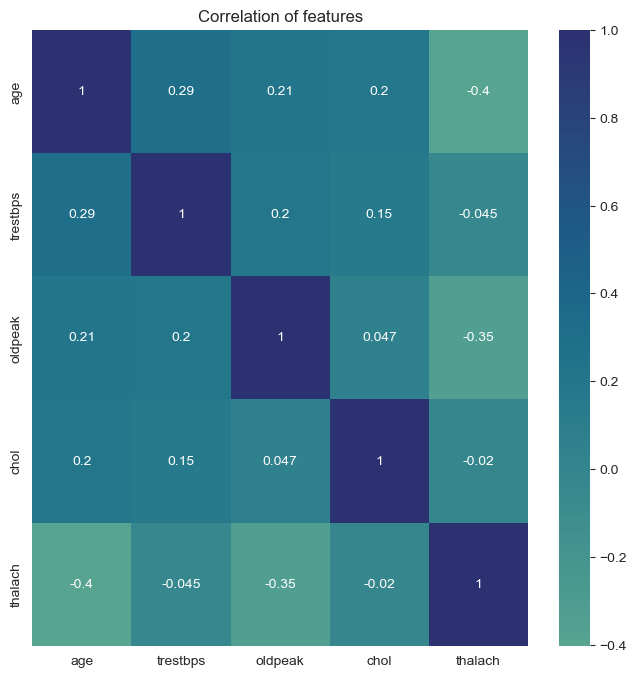

In [111]:
continues_features = ['age', 'trestbps', 'oldpeak', 'chol', 'thalach']
corr = df[continues_features].corr()

plt.figure(figsize=(8,8))
plt.title("Correlation of features")
sns.heatmap( corr, annot=True, cmap='crest', center=0)

***Some Correlations can be found from this heatmap: (more than 0.25)***

*Positive Corrrelation* between age & trestbps.

*Negative Corrrelation* between age & thalach, oldpeak & thalach.

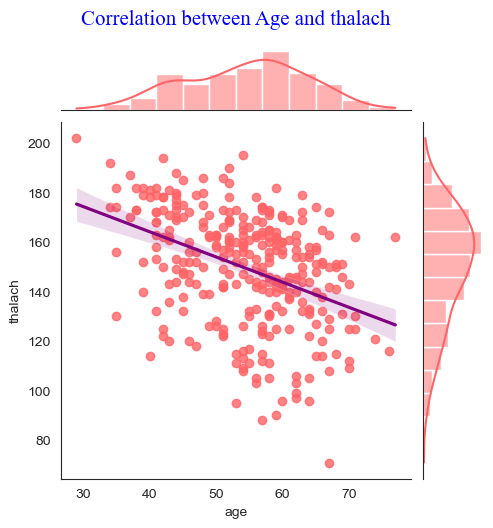

In [112]:
sns.set_style('white')
sns.jointplot(x="age", y="thalach", data=df,
            kind="reg",
            color="#FF6467", height=5,
            joint_kws={"line_kws": {"color": "purple"}})
plt.title("Correlation between Age and thalach", y=1.25, fontdict=font_title)
plt.show()


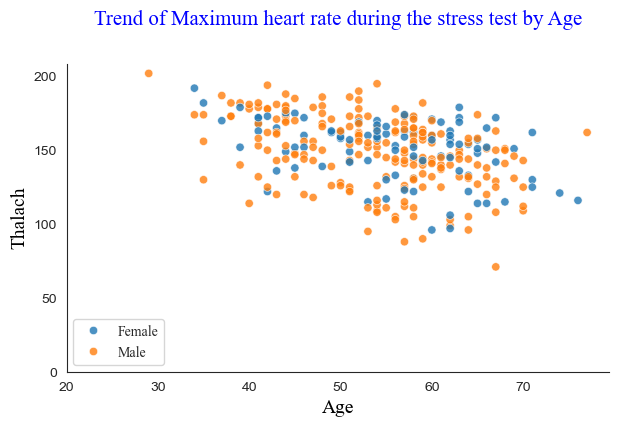

In [115]:
fig, ax = plt.subplots(figsize=(7,4))
sns.scatterplot(x='age', y='thalach', data=df, hue='sex', alpha=0.8)
ax.set_xlabel("Age", fontdict=font1)
ax.set_ylabel("Thalach", fontdict=font1)
ax.set_title("Trend of Maximum heart rate during the stress test by Age", fontdict=font_title, y=1.1)
ax.set_xticks(range(20,80,10))
ax.set_yticks(range(0,205,50))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Female', 'Male'], loc='lower left',prop={'family': 'Times New Roman'})

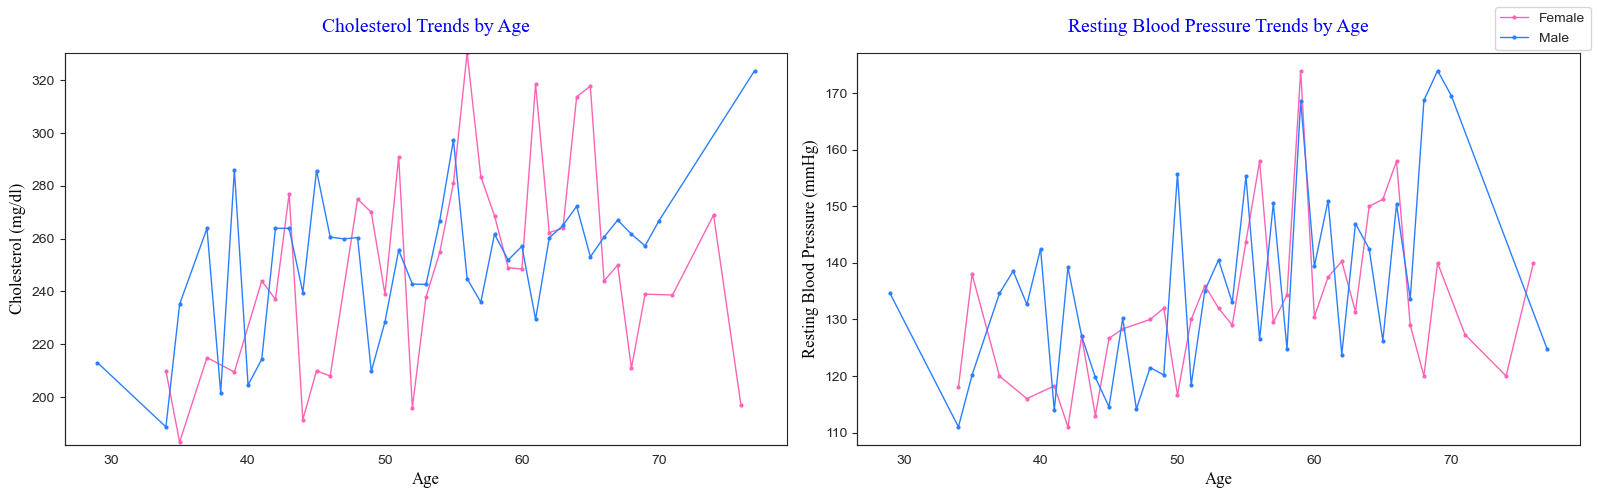

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

df_female = df[df['sex'] == 0]
df_male = df[df['sex'] == 1]
color_f = '#FB64B6'
color_m = '#2B7FFF'
#Cholestrol chart:
female_chol = df_female.groupby('age')['chol'].mean().sort_index()
male_chol = df_male.groupby('age')['chol'].mean().sort_index()

ax1.plot(female_chol.index, female_chol.values, color=color_f, marker='o', 
         linewidth=1, markersize=2, label='Female')
ax1.set_xlabel('Age', fontsize=12, fontdict=font1)
ax1.set_ylabel('Cholesterol (mg/dl)', fontsize=12, fontdict=font1)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1_twin = ax1.twinx()
ax1_twin.plot(male_chol.index, male_chol.values, color=color_m, marker='o', 
         linewidth=1, markersize=2, label='Male')
ax1.set_title('Cholesterol Trends by Age', fontsize=14, fontdict=font_title, pad=15)
y_min = min(female_chol.min(), male_chol.min())
y_max = max(female_chol.max(), male_chol.max())
ax1.set_ylim(y_min, y_max)
ax1_twin.set_yticks([])
fig.legend()

#trestbps chart:
female_tbps = df_female.groupby('age')['trestbps'].mean().sort_index()
male_tbps = df_male.groupby('age')['trestbps'].mean().sort_index()

ax2.plot(female_tbps.index, female_tbps.values, color=color_f, marker='o', 
         linewidth=1, markersize=2, label='Female')
ax2.set_xlabel('Age', fontsize=12, fontdict=font1)
ax2.set_ylabel('Resting Blood Pressure (mmHg)', fontsize=12, fontdict=font1)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2_twin = ax2.twinx()
ax2_twin.plot(male_tbps.index, male_tbps.values, color=color_m, marker='o', 
         linewidth=1, markersize=2, label='Male')
ax2.set_title('Resting Blood Pressure Trends by Age', fontsize=14, fontdict=font_title, pad=15)
y_min = min(female_chol.min(), male_chol.min())
y_max = max(female_chol.max(), male_chol.max())
ax2_twin.set_yticks([])
ax1.set_ylim(y_min, y_max)

plt.tight_layout()

### A Paiplot of features 

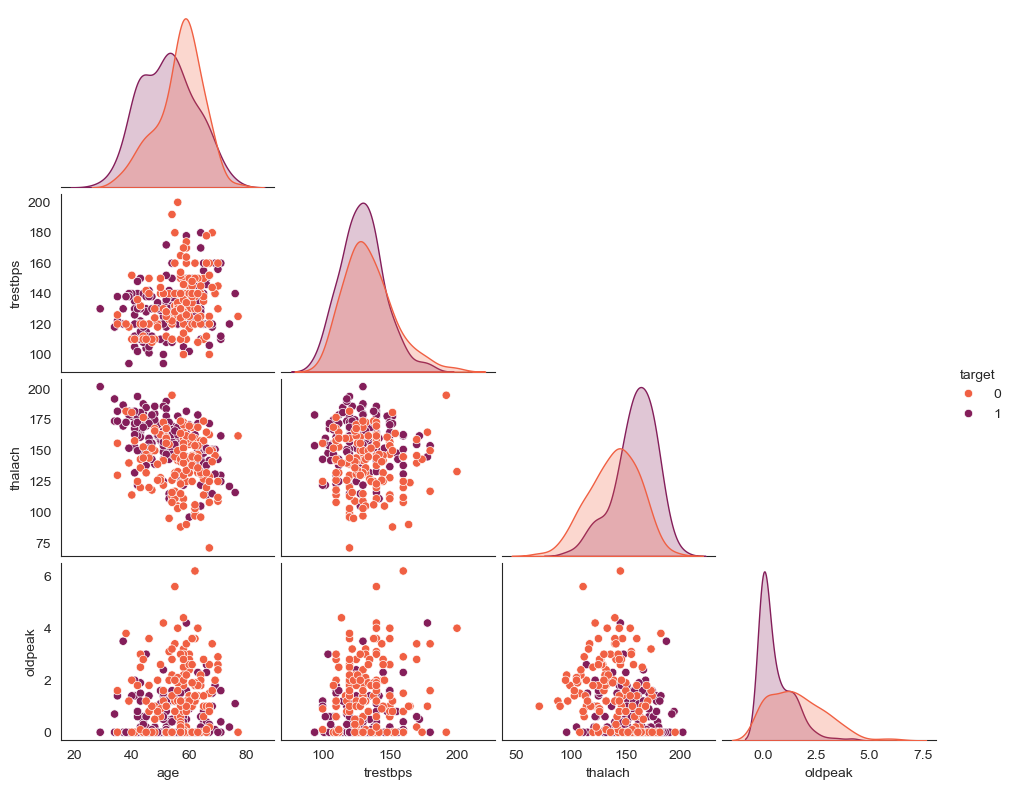

In [ ]:
g = sns.pairplot(df.loc[:, ['age', 'trestbps', 'thalach', 'oldpeak', 'target']], hue='target', palette='rocket_r', height=2, aspect=1.2, corner=True)

The End!